In [5]:
import os
import os.path as op

import importlib

import numpy as np
import pandas as pd

import nibabel as nib
from nilearn import datasets, image

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpecFromSubplotSpec

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from seaborn import kdeplot

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import networkx as nx
from time import perf_counter

import h5py

import dgsp
import bimod_plots as plot

import data_load as dload
import bundle as b_utils

In [2]:
import sys
path_to_effective = "../../effectivedelay_estimation"
sys.path.append(path_to_effective)

from src import regmod
from src import utils
from src import solver

path_to_ressources = op.join(path_to_effective, "resources")
path_to_data = "/Users/acionca/data"
path_to_ec = "./results/atlas_correspondence"

path_to_mstruct = "/Users/acionca/data/microstructure_connectomes_HCP_3T"
path_to_lobe = "./results/atlas_correspondence"

path_to_benchmark = "/Users/acionca/code/dGSP/dSVD/results/BrainKmeans"

There are 141 nodes in the graph
54.08% of connections remain  after thresholding
Removing 4.16% negative weights from EC matrix


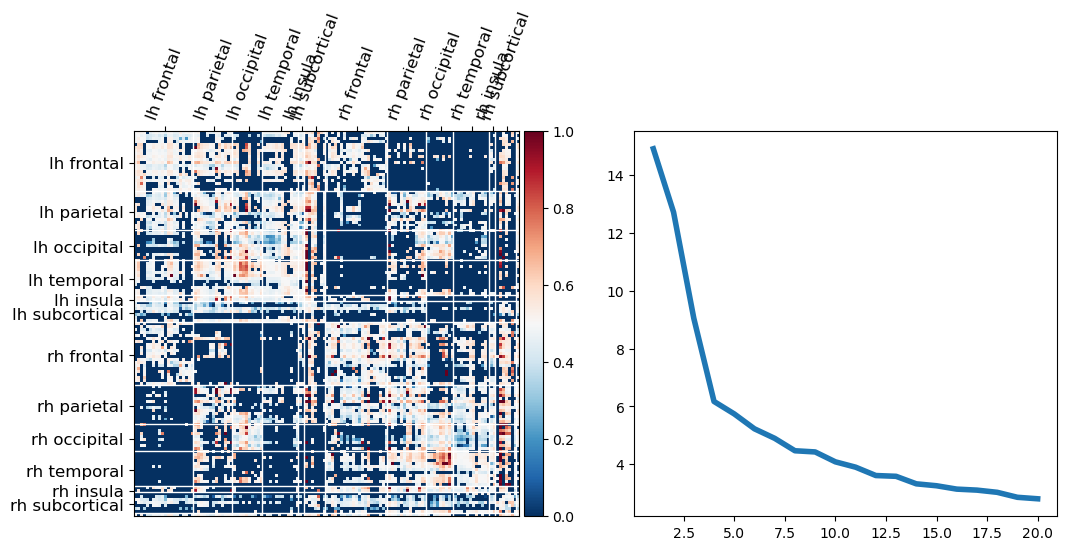

In [8]:
importlib.reload(dload)
importlib.reload(dgsp)
importlib.reload(b_utils)
importlib.reload(plot)

all_scales = [1, 2, 3, 4]

use_delay = False
k_threshold = 0
b_thresh = 0
slines_theshold = 5

struct_type = ""

scale = 2

k_matrix, labels, node_centers = dload.load_bundle_graph(path_to_data=path_to_ressources,
                                                         data_suffix="Laus2018_",
                                                         scale=scale,
                                                         b_prob_threshold=0,
                                                         slines_theshold=slines_theshold,
                                                         log_slines=False,
                                                         normalize_slines=False,
                                                         verbose=True)

labels, k_matrix = b_utils.fix_thalamus(labels, matrix=k_matrix)
k_matrix[k_matrix < b_thresh] = 0

# ec_data = dload.load(op.join(path_to_ec, f"Laus2018_EffConnFromSch414-scale{scale}.pkl"))
# ec_data = dload.load(op.join(path_to_ec, f"Laus2018_EffConnFromSch414-scale{scale}OneThal.pkl"))
# ec_mat = ec_data["conv"]
# # print(f"Removing {np.sum(ec_mat < 0)/ec_mat.size*100:.2f}% negative weights from EC matrix")
# ec_mat[ec_mat < 0] = 0

ec_mat = dload.get_ec_data(scale=scale, path_to_ec=path_to_ec, remove_neg=True, fix_thal=True)

# labels = b_utils.fix_thalamus(labels, matrix=None)

dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                      where=(ec_mat + ec_mat.T) > 1e-5,
                      out=np.zeros_like(ec_mat))
graph = (k_matrix > 0) * dir_ratio

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
V = Vh.T

n_nodes = len(S)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

order_by_lobe, lobe_sizes, lobe_labels, lobe_df = dload.get_lobe_info(scale, labels, path_to_lobe=path_to_lobe)

axes[0].imshow(graph[order_by_lobe][:, order_by_lobe], cmap="RdBu_r", interpolation="none")
plot.add_cbar(fig ,axes[0])
plot.plot_lobe_lines(axes[0], lobe_sizes, lobe_labels)

nshow = 20
axes[1].plot(np.arange(nshow)+1, S[:nshow], lw=4, zorder=0)

## Consensus Clustering

In [5]:
importlib.reload(dgsp)

from time import perf_counter

n_vec_max = 20
scale_factor = S[:n_vec_max] ** 2

# n_kmeans = 40
n_trials = 50
n_init = 50
dthresh = 0
selected_sort = 0

# all_n_kmeans = np.arange(10, 250, 5)
# all_n_kmeans = np.arange(10, 100, 1)
all_n_kmeans = np.arange(10, 80, 1)

all_labels = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=np.int8)
all_labels_fix = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=np.int8)

cons_lab = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=np.int8)
cons_lab_fix = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=np.int8)

all_c_within = np.zeros(len(all_n_kmeans))
all_c_between = np.zeros(len(all_n_kmeans))

all_c_within_fix = np.zeros(len(all_n_kmeans))
all_c_between_fix = np.zeros(len(all_n_kmeans))

avg_cons = np.zeros((np.sum(graph != 0), np.sum(graph != 0)), dtype=int)
avg_cons_fix = np.zeros((np.sum(graph != 0), np.sum(graph != 0)), dtype=int)
reorder = False

bm_fname = "_".join([
    f"brain_consensus-EC",
    f"scale{scale}",
    f"nvec{n_vec_max}",
    f"trials{n_trials}",
    f"ninit{n_init}",
    f"kmeans{all_n_kmeans[0]}-{all_n_kmeans[-1]}",
    f"slines_thresh{slines_theshold}",
    f"ustruct{struct_type}",
    f"dthresh{dthresh}",
    f"selected{selected_sort}.pkl"])

if op.isfile(op.join(path_to_benchmark, bm_fname)):
    data = dload.load(op.join(path_to_benchmark, bm_fname))
    cons_lab = data["cons_lab"]
    cons_lab_fix = data["cons_lab_fix"]
    all_c_within = data["all_c_within"]
    all_c_between = data["all_c_between"]
    all_c_within_fix = data["all_c_within_fix"]
    all_c_between_fix = data["all_c_between_fix"]
    avg_cons = data["avg_cons"]
    avg_cons_fix = data["avg_cons_fix"]
else:

    njobs = 1

    parallel = Parallel(n_jobs=np.min([14, n_trials]), return_as="generator_unordered")
    counter = tqdm(total=len(all_n_kmeans)*n_trials)

    t_cl = []
    t_co = []
    t_fast = []
    t_cs = []

    # for k_i, n_kmeans in tqdm(enumerate(all_n_kmeans), total=len(all_n_kmeans)):
    for k_i, n_kmeans in enumerate(all_n_kmeans):
        t_1 = perf_counter()
        gen = parallel(delayed(dgsp.edge_bicommunities)(
            graph, U, V, 
            n_vec_max,
            method="kmeans",
            n_kmeans=n_kmeans,
            verbose=False,
            max_k=50,
            scale_S=scale_factor,
            clust_only=True,
            undirected=True,
            kwargs_kmeans1={"n_init":n_init, "init":"random"},
            kwargs_kmeans2={"n_init":1, "tol":1e-10},
            dthresh=dthresh,
            ) for _ in range(n_trials))
        
        for t, labs in enumerate(gen):
            all_labels[k_i, t] = labs[0]
            all_labels_fix[k_i, t] = labs[1]
            counter.update(1)

        t_2 = perf_counter()
        t_cl.append(t_2 - t_1)
        # print(f"Clustering took {t_cl[-1]:.2f} seconds (mean: {np.mean(t_cl):1.2f} s)")

        cons, cons_lab[k_i] = dgsp.consensus_matrix(all_labels[k_i], reorder=reorder, consensus_labels=True, fast=True, njobs=njobs)
        cons_fix, cons_lab_fix[k_i] = dgsp.consensus_matrix(all_labels_fix[k_i], reorder=reorder, consensus_labels=True, fast=True, njobs=njobs)

        t_3 = perf_counter()
        t_co.append(t_3 - t_2)
        # print(f"Consensus matrix computation took {t_co[-1]:.2f} seconds (mean: {np.mean(t_co):1.2f} s)")

        avg_cons += cons
        avg_cons_fix += cons_fix

        all_c_within[k_i], all_c_between[k_i] = dgsp.consensus_score(cons, cons_lab[k_i], is_sorted=not reorder)
        all_c_within_fix[k_i], all_c_between_fix[k_i] = dgsp.consensus_score(cons_fix, cons_lab_fix[k_i], is_sorted=not reorder)

        t_4 = perf_counter()
        t_cs.append(t_4 - t_3)
        # print(f"Consensus score took {t_cs[-1]:.2f} seconds (mean: {np.mean(t_cs):1.2f} s)")

    avg_cons = avg_cons.astype(float) / (len(all_n_kmeans) * n_trials)
    avg_cons_fix = avg_cons_fix.astype(float) / (len(all_n_kmeans) * n_trials)

    print(f"Consensus Clustering Done")
    print(f"\t- Clustering took {np.mean(t_cl):1.2f}s on average")
    print(f"\t- Consensus Matrix took {np.mean(t_co):1.2f}s on average")
    print(f"\t- Consensus Score took {np.mean(t_cs):1.2f}s on average")

    counter.close()

    dload.save(op.join(path_to_benchmark, bm_fname),
                {"all_n_kmeans": all_n_kmeans,
                 "cons_lab": cons_lab,
                 "cons_lab_fix": cons_lab_fix,
                 "all_c_within": all_c_within,
                 "all_c_between": all_c_between,
                 "all_c_within_fix": all_c_within_fix,
                 "all_c_between_fix": all_c_between_fix,
                 "avg_cons": avg_cons,
                 "avg_cons_fix": avg_cons_fix})

  0%|          | 0/3500 [00:00<?, ?it/s]

KeyboardInterrupt: 

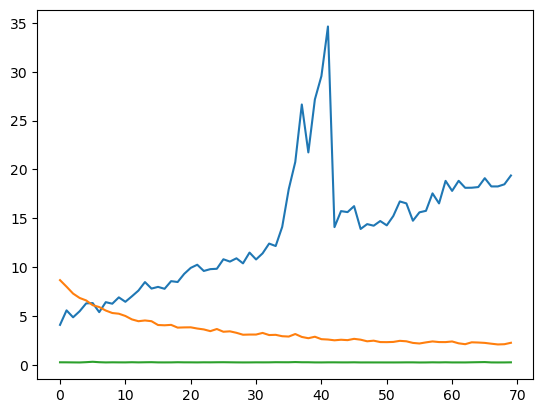

In [10]:
plt.plot(t_cl, label="Clustering")
plt.plot(t_co, label="Consensus")
plt.plot(t_cs, label="Consensus Score")

- Took 2h 38min for scale 3 (3500 iterations)

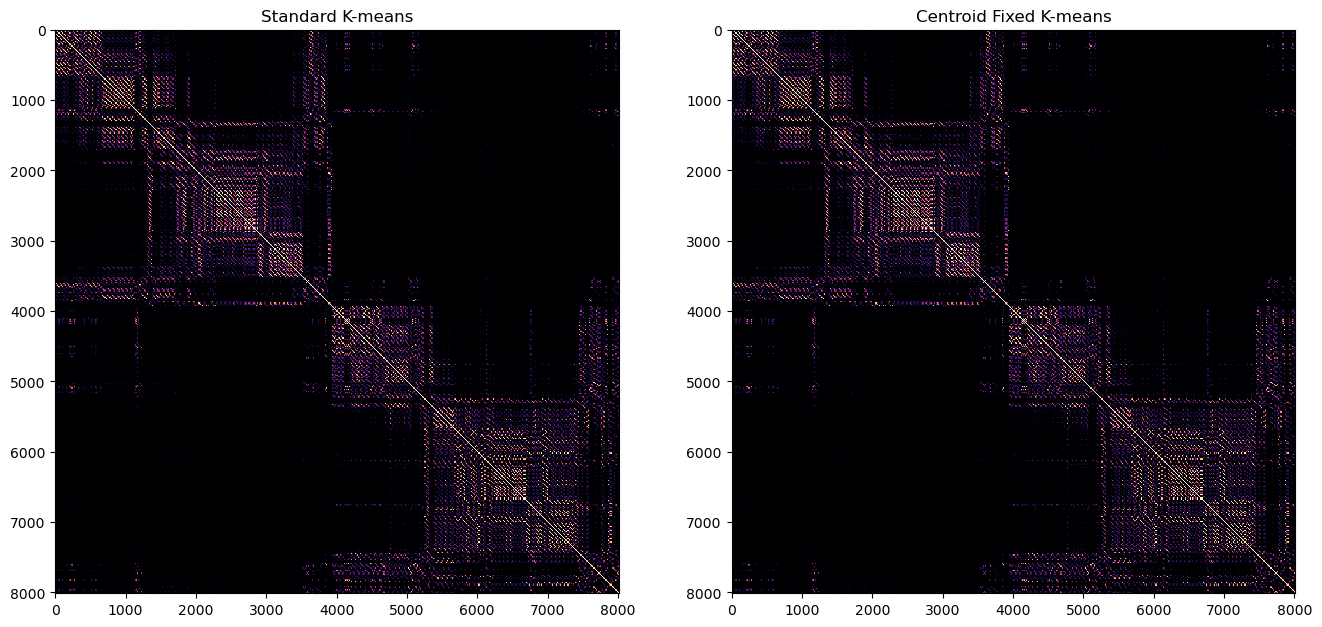

In [6]:
fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

axes[0].set_title("Standard K-means")
axes[0].imshow(avg_cons, cmap="magma",
               vmin=0, vmax=1,
               interpolation="none")

axes[1].set_title("Centroid Fixed K-means")
axes[1].imshow(avg_cons_fix, cmap="magma",
               vmin=0, vmax=1,
               interpolation="none")

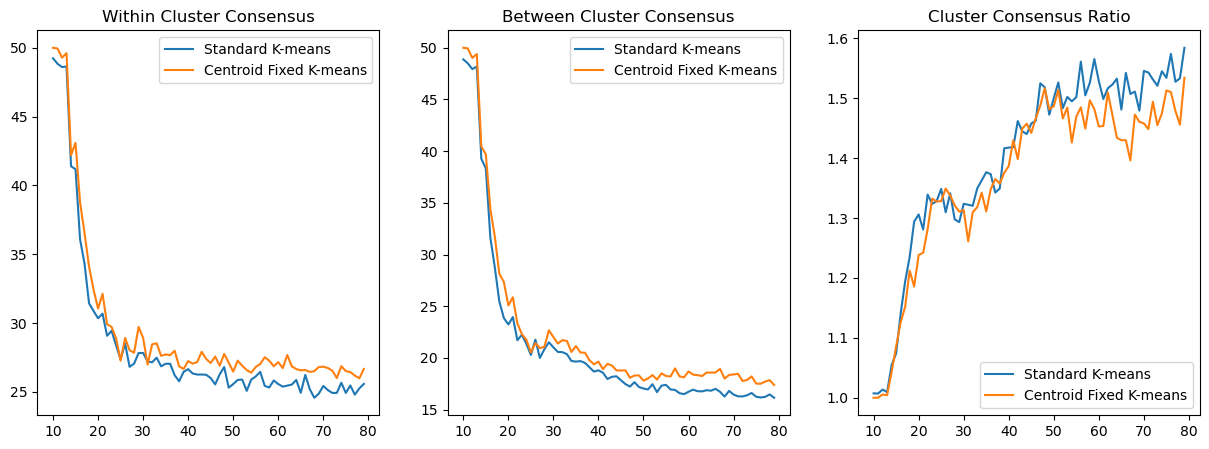

In [7]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(all_n_kmeans, all_c_within, label="Standard K-means")
axes[0].plot(all_n_kmeans, all_c_within_fix, label="Centroid Fixed K-means")
axes[0].set_title("Within Cluster Consensus")
axes[0].legend()

axes[1].plot(all_n_kmeans, all_c_between, label="Standard K-means")
axes[1].plot(all_n_kmeans, all_c_between_fix, label="Centroid Fixed K-means")
axes[1].set_title("Between Cluster Consensus")
axes[1].legend()

c_ratio = all_c_within / all_c_between
c_ratio_fix = all_c_within_fix / all_c_between_fix
# c_ratio_dist4 = all_c_within / all_c_between
# c_ratio_fix_dist4 = all_c_within_fix / all_c_between_fix

axes[2].plot(all_n_kmeans, c_ratio, label="Standard K-means")
axes[2].plot(all_n_kmeans, c_ratio_fix, label="Centroid Fixed K-means")
axes[2].set_title("Cluster Consensus Ratio")
axes[2].legend()

[26 28 37 29 44 41 15 49 23 38]
[79 48 51 75 76 62 58 72 47 50]


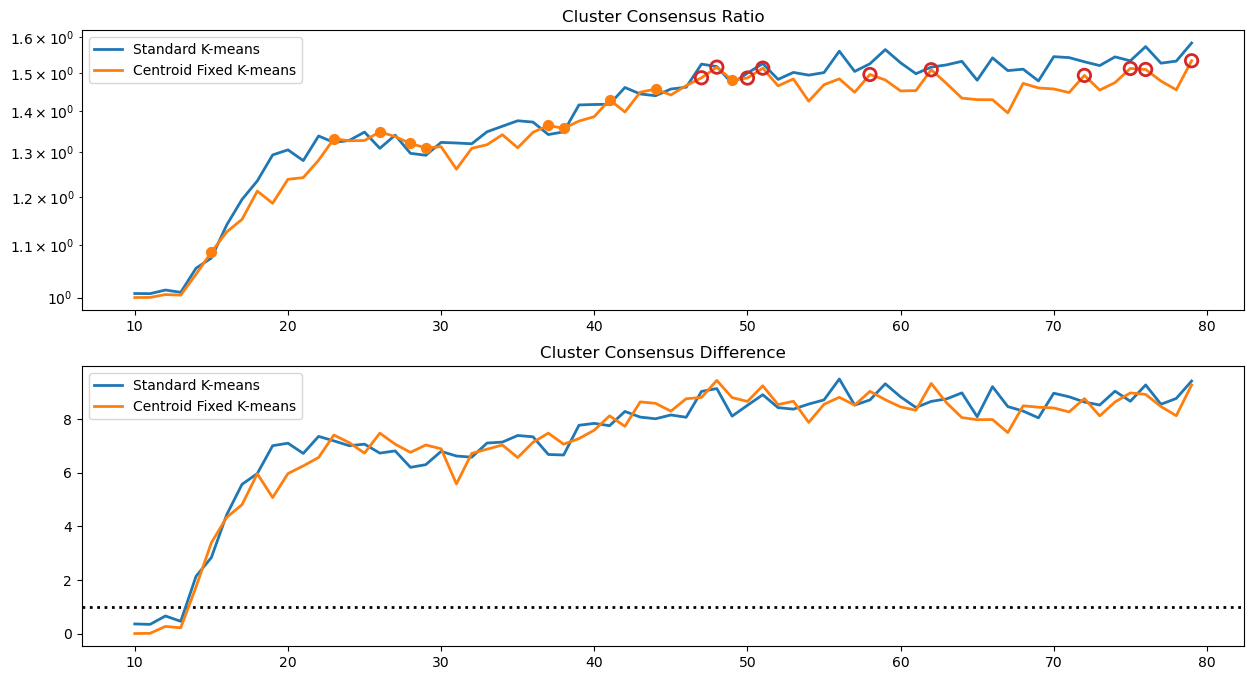

In [8]:
fig, axes = plt.subplots(nrows=2, figsize=(15, 8))

n_best = 10
best_ratio = np.flip(np.argsort(c_ratio_fix))
best_r_diff = np.flip(np.argsort(c_ratio_fix - c_ratio))

axes[0].plot(all_n_kmeans, c_ratio, label="Standard K-means", lw=2, zorder=1)
axes[0].plot(all_n_kmeans, c_ratio_fix, label="Centroid Fixed K-means", lw=2, zorder=1)
axes[0].set_title("Cluster Consensus Ratio")
axes[0].legend()
axes[0].set_yscale("log")

all_n_kmeans = np.array(all_n_kmeans)
print(all_n_kmeans[best_r_diff[:n_best]])
for i in best_r_diff[:n_best]:
    axes[0].scatter(all_n_kmeans[i], c_ratio_fix[i], s=50, c='tab:orange', marker='o')

print(all_n_kmeans[best_ratio[:n_best]])
for i in best_ratio[:n_best]:
    axes[0].scatter(all_n_kmeans[i], c_ratio_fix[i], s=80, c='none', marker='o', edgecolor="tab:red", lw=2)

axes[1].axhline(1, color="k", lw=2, ls=':')
axes[1].axhline(0, color="w", lw=1)
axes[1].plot(all_n_kmeans, all_c_within-all_c_between, label="Standard K-means", lw=2)
axes[1].plot(all_n_kmeans, all_c_within_fix-all_c_between_fix, label="Centroid Fixed K-means", lw=2)
axes[1].set_title("Cluster Consensus Difference")
axes[1].legend()

# Running in Bulk

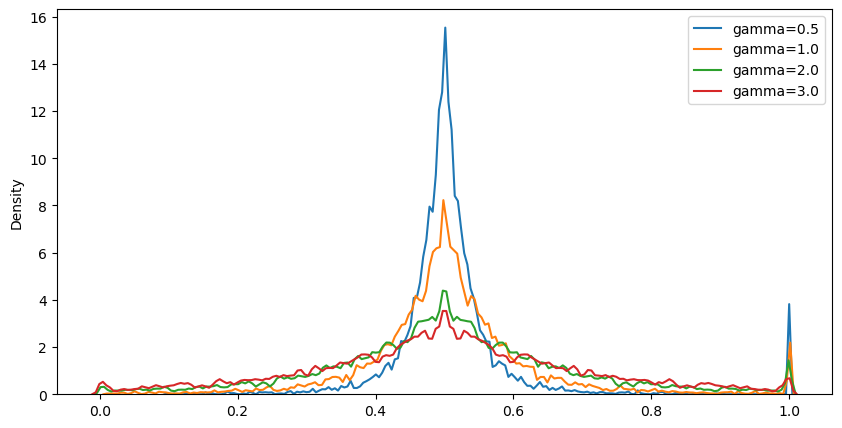

In [27]:
fig, axes = plt.subplots(figsize=(10, 5))

for gamma in [0.5, 1.0, 2.0, 3.0]:
    k_matrix, labels, node_centers = dload.load_bundle_graph(path_to_data=path_to_ressources,
                                                            data_suffix="Laus2018_",
                                                            scale=scale,
                                                            b_prob_threshold=0,
                                                            slines_theshold=slines_theshold,
                                                            log_slines=False,
                                                            normalize_slines=False,
                                                            verbose=False)

    labels, k_matrix = b_utils.fix_thalamus(labels, matrix=k_matrix)
    k_matrix[k_matrix < b_thresh] = 0

    ec_mat = dload.get_ec_data(scale=scale, path_to_ec=path_to_ec, remove_neg=True, fix_thal=True, verbose=False)
    ec_mat /= ec_mat.max()
    ec_mat = ec_mat ** gamma

    dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                        where=(ec_mat + ec_mat.T) > 1e-5,
                        out=np.zeros_like(ec_mat))
    graph = (k_matrix > 0) * dir_ratio

    kdeplot(dir_ratio[dir_ratio > 0], bw_adjust=0.1, label=f"gamma={gamma}", ax=axes)
axes.legend()

In [ ]:
all_scales = [1, 2, 3, 4]
all_scales = [1, 2, 3]

struct_type = ""
use_delay = False
k_threshold = 0
b_thresh = 0
slines_theshold = 5

n_trials = 50
n_init = 50
dthresh = 0
selected_sort = 0

run_fix = False

gamma = 2
all_n_kmeans = np.arange(10, 80, 1)
# all_nvecs = [5, 10, 20, 30]
# all_gammas = [1, 1.5, 2, 2.5, 3]
all_nvecs = [10, 20]
all_gammas = [1, 2]

for gamma in all_gammas:
    for n_vec_max in all_nvecs:
        for scale in all_scales:
            k_matrix, labels, node_centers = dload.load_bundle_graph(path_to_data=path_to_ressources,
                                                                    data_suffix="Laus2018_",
                                                                    scale=scale,
                                                                    b_prob_threshold=0,
                                                                    slines_theshold=slines_theshold,
                                                                    log_slines=False,
                                                                    normalize_slines=False,
                                                                    verbose=False)

            labels, k_matrix = b_utils.fix_thalamus(labels, matrix=k_matrix)
            k_matrix[k_matrix < b_thresh] = 0

            ec_mat = dload.get_ec_data(scale=scale, path_to_ec=path_to_ec, remove_neg=True, fix_thal=True, verbose=False)
            ec_mat /= ec_mat.max()
            ec_mat = ec_mat ** gamma

            dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                                where=(ec_mat + ec_mat.T) > 1e-5,
                                out=np.zeros_like(ec_mat))
            graph = (k_matrix > 0) * dir_ratio

            U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
            V = Vh.T

            n_nodes = len(S)

            scale_factor = S[:n_vec_max] ** 2

            all_labels = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=np.int8)
            all_labels_fix = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=np.int8)

            cons_lab = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=np.int8)
            cons_lab_fix = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=np.int8)

            all_c_within = np.zeros(len(all_n_kmeans))
            all_c_between = np.zeros(len(all_n_kmeans))

            all_c_within_fix = np.zeros(len(all_n_kmeans))
            all_c_between_fix = np.zeros(len(all_n_kmeans))

            avg_cons = np.zeros((np.sum(graph != 0), np.sum(graph != 0)), dtype=int)
            avg_cons_fix = np.zeros((np.sum(graph != 0), np.sum(graph != 0)), dtype=int)
            reorder = False

            bm_fname = "_".join([
                f"brain_consensus-EC",
                f"scale{scale}",
                f"nvec{n_vec_max}",
                f"trials{n_trials}",
                f"ninit{n_init}",
                f"kmeans{all_n_kmeans[0]}-{all_n_kmeans[-1]}",
                f"slines_thresh{slines_theshold}",
                f"ustruct{struct_type}"*(struct_type != ""),
                f"dthresh{dthresh}"*(dthresh != 0),
                f"gamma{gamma}"*(gamma != 1),
                f"selected{selected_sort}"*(selected_sort != 0)
                ])
            bm_fname += ".pkl"

            if op.isfile(op.join(path_to_benchmark, bm_fname)):
                data = dload.load(op.join(path_to_benchmark, bm_fname))
                cons_lab = data["cons_lab"]
                cons_lab_fix = data["cons_lab_fix"]
                all_c_within = data["all_c_within"]
                all_c_between = data["all_c_between"]
                all_c_within_fix = data["all_c_within_fix"]
                all_c_between_fix = data["all_c_between_fix"]
                avg_cons = data["avg_cons"]
                avg_cons_fix = data["avg_cons_fix"]
            else:

                njobs = 1

                parallel = Parallel(n_jobs=np.min([14, n_trials]), return_as="generator_unordered")
                counter = tqdm(total=len(all_n_kmeans)*n_trials)

                t_cl = []
                t_co = []
                t_fast = []
                t_cs = []

                # for k_i, n_kmeans in tqdm(enumerate(all_n_kmeans), total=len(all_n_kmeans)):
                for k_i, n_kmeans in enumerate(all_n_kmeans):
                    t_1 = perf_counter()
                    gen = parallel(delayed(dgsp.edge_bicommunities)(
                        graph, U, V, 
                        n_vec_max,
                        method="kmeans",
                        n_kmeans=n_kmeans,
                        verbose=False,
                        max_k=50,
                        scale_S=scale_factor,
                        clust_only=True,
                        undirected=True,
                        kwargs_kmeans1={"n_init":n_init, "init":"random"},
                        kwargs_kmeans2={"n_init":1, "tol":1e-10},
                        dthresh=dthresh,
                        ) for _ in range(n_trials))
                    
                    for t, labs in enumerate(gen):
                        all_labels[k_i, t] = labs[0]
                        all_labels_fix[k_i, t] = labs[1]
                        counter.update(1)

                    t_2 = perf_counter()
                    t_cl.append(t_2 - t_1)
                    # print(f"Clustering took {t_cl[-1]:.2f} seconds (mean: {np.mean(t_cl):1.2f} s)")

                    cons, cons_lab[k_i] = dgsp.consensus_matrix(all_labels[k_i], reorder=reorder, consensus_labels=True, fast=True, njobs=njobs)
                    if run_fix:
                        cons_fix, cons_lab_fix[k_i] = dgsp.consensus_matrix(all_labels_fix[k_i], reorder=reorder, consensus_labels=True, fast=True, njobs=njobs)

                    t_3 = perf_counter()
                    t_co.append(t_3 - t_2)
                    # print(f"Consensus matrix computation took {t_co[-1]:.2f} seconds (mean: {np.mean(t_co):1.2f} s)")

                    avg_cons += cons
                    if run_fix:
                        avg_cons_fix += cons_fix

                    all_c_within[k_i], all_c_between[k_i] = dgsp.consensus_score(cons, cons_lab[k_i], is_sorted=not reorder)
                    if run_fix:
                        all_c_within_fix[k_i], all_c_between_fix[k_i] = dgsp.consensus_score(cons_fix, cons_lab_fix[k_i], is_sorted=not reorder)

                    t_4 = perf_counter()
                    t_cs.append(t_4 - t_3)
                    # print(f"Consensus score took {t_cs[-1]:.2f} seconds (mean: {np.mean(t_cs):1.2f} s)")

                avg_cons = avg_cons.astype(float) / (len(all_n_kmeans) * n_trials)
                if run_fix:
                    avg_cons_fix = avg_cons_fix.astype(float) / (len(all_n_kmeans) * n_trials)
                else:
                    avg_cons_fix = None

                print(f"Consensus Clustering Done")
                print(f"\t- Clustering took {np.mean(t_cl):1.2f}s on average")
                print(f"\t- Consensus Matrix took {np.mean(t_co):1.2f}s on average")
                print(f"\t- Consensus Score took {np.mean(t_cs):1.2f}s on average")

                counter.close()

                dload.save(op.join(path_to_benchmark, bm_fname),
                            {"graph": graph,
                            "all_n_kmeans": all_n_kmeans,
                            "cons_lab": cons_lab,
                            "cons_lab_fix": cons_lab_fix,
                            "all_c_within": all_c_within,
                            "all_c_between": all_c_between,
                            "all_c_within_fix": all_c_within_fix,
                            "all_c_between_fix": all_c_between_fix,
                            "avg_cons": avg_cons,
                            "avg_cons_fix": avg_cons_fix})

  0%|          | 0/3500 [00:00<?, ?it/s]

Consensus Clustering Done
	- Clustering took 4.09s on average
	- Consensus Matrix took 0.29s on average
	- Consensus Score took 0.03s on average


  0%|          | 0/3500 [00:00<?, ?it/s]

Consensus Clustering Done
	- Clustering took 10.56s on average
	- Consensus Matrix took 1.53s on average
	- Consensus Score took 0.12s on average


  0%|          | 0/3500 [00:00<?, ?it/s]

...

Consensus Clustering Done
	- Clustering took 11.11s on average
	- Consensus Matrix took 1.21s on average
	- Consensus Score took 0.10s on average


  0%|          | 0/3500 [00:00<?, ?it/s]

Consensus Clustering Done
	- Clustering took 4.80s on average
	- Consensus Matrix took 0.24s on average
	- Consensus Score took 0.02s on average


  0%|          | 0/3500 [00:00<?, ?it/s]

Consensus Clustering Done
	- Clustering took 16.59s on average
	- Consensus Matrix took 1.21s on average
	- Consensus Score took 0.10s on average
